# 🛡️ ForgeShield
## Machine Learning & Anomaly Detection Analysis

**Project:** AI-Based Industrial Safety and Predictive Risk Management System

This notebook presents the supervised machine-failure classification and unsupervised anomaly-detection experiments conducted for ForgeShield.

### Objectives
- Compare multiple supervised machine-learning models
- Evaluate precision, recall, F1-score, ROC-AUC and PR-AUC
- Explicitly examine false negatives because missed failures are important in safety-oriented prediction
- Analyze unsupervised anomaly-detection methods
- Compare anomaly signals against known failure labels only as post-hoc validation
- Present the final evaluated model results without retraining the complete experiment

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate ForgeShield project root
current_path = Path.cwd().resolve()

PROJECT_ROOT = None
for path in [current_path, *current_path.parents]:
    if (path / "reports").is_dir() and (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate ForgeShield project root.")

REPORTS_DIR = PROJECT_ROOT / "reports"

# Load saved supervised-learning results
supervised_results_path = (
    REPORTS_DIR / "supervised" / "final_test_evaluation.csv"
)

threshold_results_path = (
    REPORTS_DIR / "threshold_analysis" / "oof_threshold_summary.csv"
)

supervised_results = pd.read_csv(supervised_results_path)
threshold_results = pd.read_csv(threshold_results_path)

print("Supervised results:")
display(supervised_results)

print("\nOOF threshold analysis:")
display(threshold_results)

Supervised results:


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Gradient Boosting,0.35,0.9905,0.901639,0.808824,0.852713,0.974135,0.897404,1926,6,13,55
1,Random Forest,0.56,0.9895,0.927273,0.750000,0.829268,0.975848,0.844090,1928,4,17,51
2,XGBoost,0.74,0.9895,0.885246,0.794118,0.837209,0.979989,0.864085,1925,7,14,54
3,SVM,0.31,0.9720,0.573171,0.691176,0.626667,0.969956,0.654985,1897,35,21,47



OOF threshold analysis:


,model,best_f1_threshold,best_f1,high_recall_threshold,high_recall_precision,high_recall_recall,high_recall_false_negatives
0,Gradient Boosting,0.35,0.835938,NaN,NaN,NaN,NaN
1,Random Forest,0.56,0.828866,0.14,0.401639,0.904059,26.0
2,XGBoost,0.74,0.826772,0.05,0.368421,0.904059,26.0
3,SVM,0.31,0.650177,0.05,0.273438,0.904059,26.0


In [6]:
# Final supervised-model comparison

results = supervised_results.copy()

display(
    results[
        [
            "model",
            "threshold",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "false_negatives"
        ]
    ].round(3)
)

,model,threshold,precision,recall,f1,roc_auc,pr_auc,false_negatives
0,Gradient Boosting,0.35,0.902,0.809,0.853,0.974,0.897,13
1,Random Forest,0.56,0.927,0.750,0.829,0.976,0.844,17
2,XGBoost,0.74,0.885,0.794,0.837,0.980,0.864,14
3,SVM,0.31,0.573,0.691,0.627,0.970,0.655,21


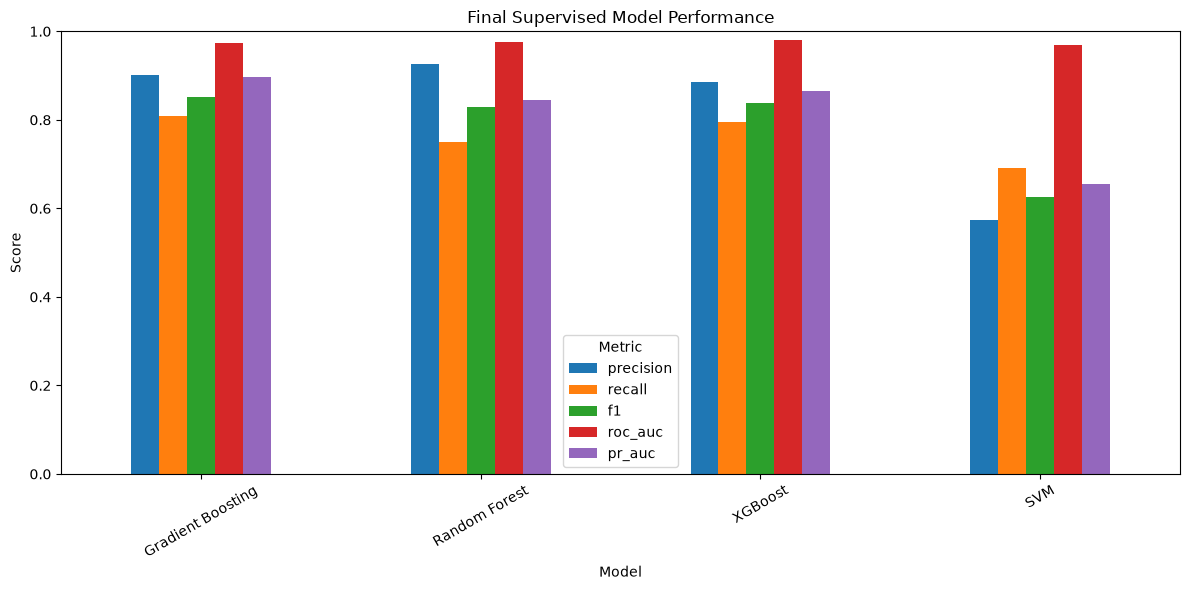

In [3]:
# Compare final model metrics

metric_columns = [
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

plot_data = results.set_index("model")[metric_columns]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Final Supervised Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

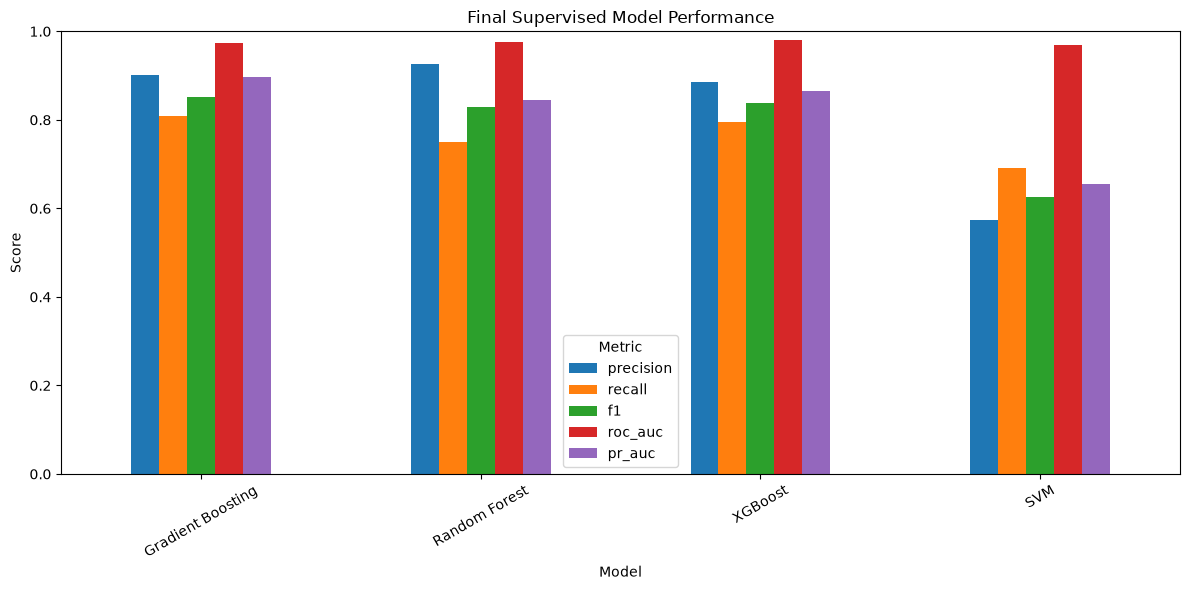

In [7]:
# Compare final model metrics

metric_columns = [
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

plot_data = results.set_index("model")[metric_columns]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Final Supervised Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

,model,recall,false_negatives
0,Gradient Boosting,0.809,13
2,XGBoost,0.794,14
1,Random Forest,0.750,17
3,SVM,0.691,21


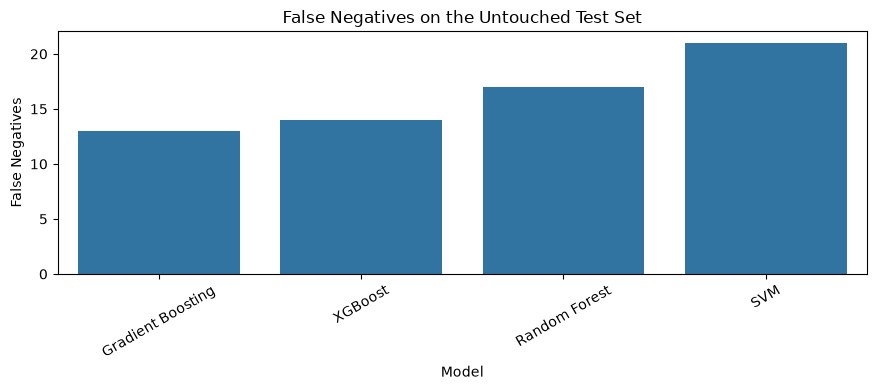

In [8]:
# False-negative analysis

fn_analysis = results[
    ["model", "recall", "false_negatives"]
].copy()

fn_analysis = fn_analysis.sort_values(
    "false_negatives",
    ascending=True
)

display(fn_analysis.round(3))

plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=fn_analysis,
    x="model",
    y="false_negatives"
)

ax.set_title("False Negatives on the Untouched Test Set")
ax.set_xlabel("Model")
ax.set_ylabel("False Negatives")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [9]:
# Load saved anomaly-detection results

anomaly_results_path = (
    REPORTS_DIR / "figures" / "anomaly" / "anomaly_detector_comparison.csv"
)

clustering_results_path = (
    REPORTS_DIR / "figures" / "anomaly" / "clustering_comparison.csv"
)

anomaly_results = pd.read_csv(anomaly_results_path)
clustering_results = pd.read_csv(clustering_results_path)

print("Anomaly detection results:")
print(anomaly_results.columns.tolist())
display(anomaly_results)

print("\nClustering results:")
print(clustering_results.columns.tolist())
display(clustering_results)

Anomaly detection results:
['model', 'anomalies_detected', 'detection_rate', 'precision', 'recall', 'f1']


,model,anomalies_detected,detection_rate,precision,recall,f1
0,Isolation Forest,700,0.350,0.074286,0.764706,0.135417
1,One-Class SVM,106,0.053,0.169811,0.264706,0.206897



Clustering results:
['model', 'clusters', 'silhouette', 'ARI']


,model,clusters,silhouette,ARI
0,K-Means,3,0.211588,-0.002217
1,DBSCAN,10,-0.258363,0.012643
2,Agglomerative,3,0.157507,0.002544


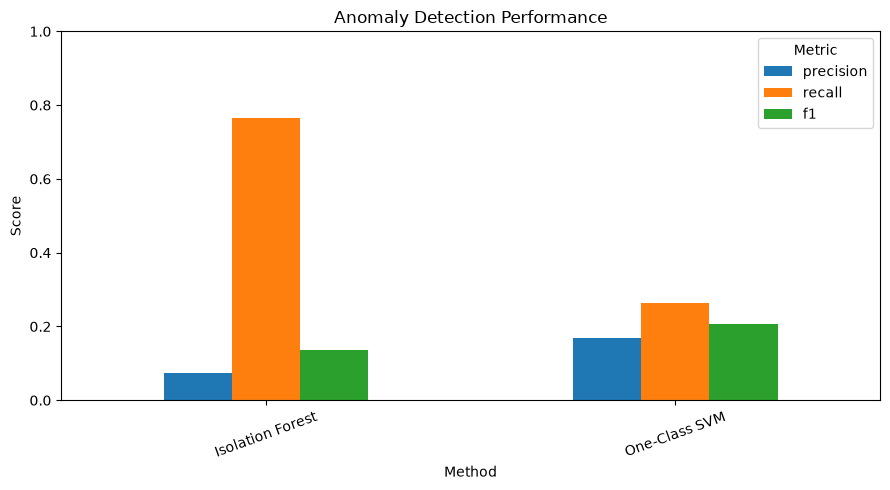

In [11]:
# Compare anomaly-detection methods

anomaly_plot = anomaly_results.set_index("model")[
    ["precision", "recall", "f1"]
]

ax = anomaly_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Anomaly Detection Performance")
ax.set_xlabel("Method")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

,model,clusters,silhouette,ARI
0,K-Means,3,0.2116,-0.0022
1,DBSCAN,10,-0.2584,0.0126
2,Agglomerative,3,0.1575,0.0025


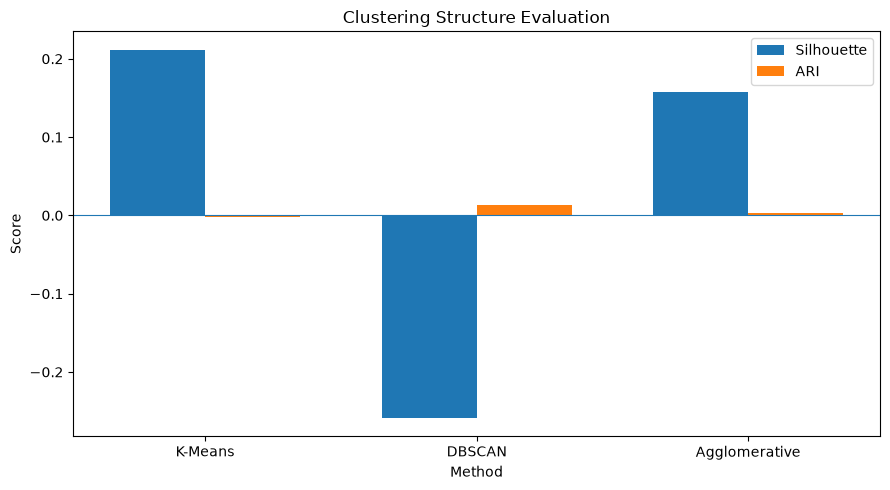

In [14]:
# Clustering structure analysis

import numpy as np

display(
    clustering_results[
        ["model", "clusters", "silhouette", "ARI"]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(clustering_results))
width = 0.35

ax.bar(
    x - width / 2,
    clustering_results["silhouette"],
    width,
    label="Silhouette"
)

ax.bar(
    x + width / 2,
    clustering_results["ARI"],
    width,
    label="ARI"
)

ax.set_title("Clustering Structure Evaluation")
ax.set_xlabel("Method")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(clustering_results["model"])
ax.axhline(0, linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()

from IPython.display import Image, display

pca_figure = (
    REPORTS_DIR
    / "figures"
    / "anomaly"
    / "pca_failure_visualization.png"
)

display(Image(filename=str(pca_figure)))

## ML & Anomaly Detection Summary

The supervised experiments evaluated multiple machine-learning approaches for machine-failure prediction. Because the AI4I dataset is highly imbalanced, the analysis emphasizes precision, recall, F1-score, PR-AUC and false-negative counts rather than accuracy alone.

Operating thresholds for the final reported models were selected from out-of-fold training predictions before evaluation on the untouched test set.

For anomaly detection, Isolation Forest identified 35.0% of the test observations as anomalous and captured 76.5% of known failure cases in the post-hoc validation. One-Class SVM flagged 5.3% of observations and captured 26.5% of known failures.

The clustering experiments produced near-zero Adjusted Rand Index values, indicating that the evaluated cluster structures did not align strongly with the known failure labels. DBSCAN also produced a negative silhouette score under the evaluated configuration.

Therefore, ForgeShield uses the continuous **Isolation Forest anomaly signal** in the unified risk layer rather than treating clustering membership as a direct machine-failure prediction.

### Key takeaway

ForgeShield combines **supervised failure probability** with **unsupervised anomaly evidence**, allowing the downstream risk engine to consider both predicted failure likelihood and unusual machine behavior.